# Marketing Campaign Effectiveness: A/B Testing and Causal Inference Analysis

## Business Problem

Organizations frequently invest in advertising campaigns to increase customer engagement and conversions. However, determining whether an advertising campaign truly causes an improvement in customer behavior requires rigorous experimentation and statistical analysis.

This project evaluates the effectiveness of a digital advertising campaign using a randomized A/B test involving 588,101 users. Participants were assigned to either a treatment group that received advertisements or a control group that received public service announcements (PSAs).

## Project Objectives

The primary objectives of this analysis are to:

* Determine whether advertisement exposure increases conversion rates.
* Measure the magnitude of the treatment effect using causal inference techniques.
* Evaluate statistical significance through hypothesis testing.
* Construct confidence intervals for the estimated treatment effect.
* Provide data-driven recommendations regarding campaign deployment.

## Business Impact

Understanding the effectiveness of advertising campaigns enables organizations to allocate marketing resources more efficiently, improve customer acquisition strategies, and maximize return on investment. Even small improvements in conversion rates can generate substantial business value when applied across large user populations.

## Success Metric

The primary success metric for this analysis is the conversion rate, defined as the proportion of users who completed the desired action after exposure to either the advertisement treatment or the PSA control condition.

The analysis will compare conversion outcomes between groups and determine whether the observed differences are statistically and practically significant.


## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\austi\OneDrive\Documents\Data Science Projects\AB Testing and Causal Inference\data\marketing_AB.csv")

df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


## Data Quality Assessment 

In [3]:
print(df.shape)

(588101, 7)


In [4]:
print(df.columns.tolist())

['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads', 'most ads day', 'most ads hour']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [6]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [7]:
df['test group'].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

## Exploratory Data Analysis 

In [8]:
pd.crosstab(
    df['test group'],
    df['converted'],
    normalize='index'
)

converted,False,True
test group,,
ad,0.974453,0.025547
psa,0.982146,0.017854


In [9]:
contingency_table = pd.crosstab(
    df['test group'],
    df['converted']
)

contingency_table

converted,False,True
test group,,
ad,550154,14423
psa,23104,420


In [10]:
from scipy.stats import chi2_contingency 

chi2, p, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square:", chi2)
print("P-Value:", p)

Chi-Square: 54.005823883685245
P-Value: 1.9989623063390075e-13


## Finding #1: Advertisement Exposure Significantly Increased Conversion Rates

Users exposed to the advertising treatment converted at a rate of 2.55%, compared to 1.79% among users exposed to the public service announcement (PSA).

A Chi-Square test confirmed that the difference was statistically significant (χ² = 54.01, p < 0.001), indicating that the observed increase in conversions is unlikely to be due to random chance.

The advertising treatment generated a 42.9% relative increase in conversion rates, suggesting that the campaign had a meaningful positive impact on customer behavior.

## Now Let's Calculate The Actual Treatment Effect

In [11]:
conversion_rates = (
    df.groupby("test group")["converted"].mean()
)
conversion_rates

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

In [12]:
treament_rate = conversion_rates["ad"]
control_rate = conversion_rates["psa"]

ate = treament_rate - control_rate 

print("Average Treatment Effect:", ate)

Average Treatment Effect: 0.007692453192201517


## Finding #2: Advertising Exposure Produced a Positive Treatment Effect

The estimated Average Treatment Effect (ATE) was 0.00769, indicating that advertisement exposure increased the probability of conversion by approximately 0.77 percentage points.

Although the absolute increase appears small, the baseline conversion rate was relatively low (1.79%), resulting in a 42.9% relative improvement in conversions.

From a business perspective, even small increases in conversion rates can generate substantial revenue gains when applied across large user populations.

## Now Let's Calculate A Confidence Interval

In [13]:
import numpy as np

treatment = df[df["test group"] == "ad"]["converted"]
control = df[df["test group"] == "psa"]["converted"]

p1 = treatment.mean()
p2 = control.mean()

n1 = len(treatment)
n2 = len(control)

se = np.sqrt(
    (p1 * (1 - p1) / n1) +
    (p2 * (1 - p2) / n2)
)

difference = p1 - p2

lower = difference - 1.96 * se
upper = difference + 1.96 * se

print("Difference:", difference)
print("95% CI:", lower, upper)

Difference: 0.007692453192201517
95% CI: 0.00595090043017032 0.009434005954232714


## Conversion Rate by Group

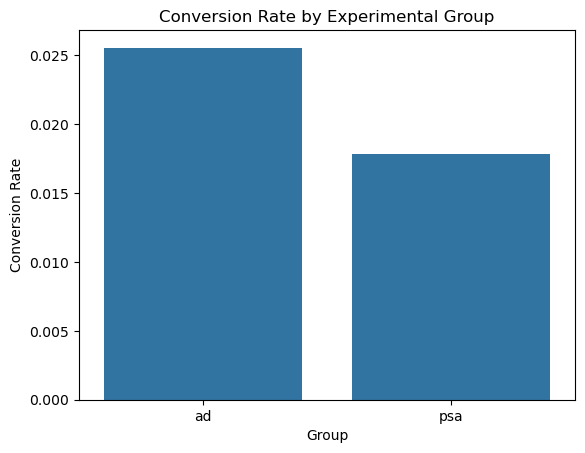

In [14]:
conversion_rates = (
    df.groupby("test group")["converted"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=conversion_rates,
    x="test group",
    y="converted"
)

plt.title("Conversion Rate by Experimental Group")
plt.ylabel("Conversion Rate")
plt.xlabel("Group")
plt.show()

## Conversion Rate by Day of Week

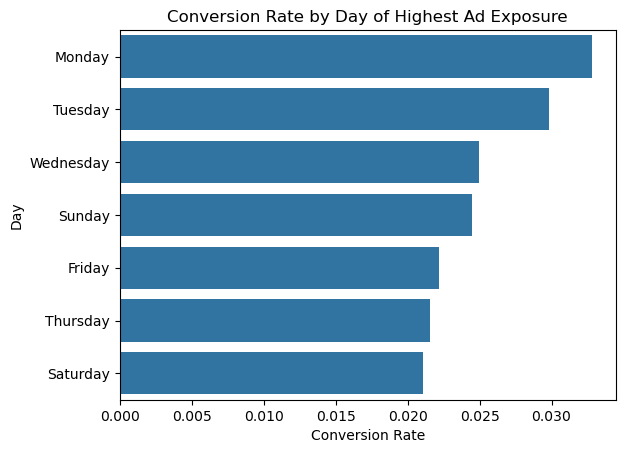

In [15]:
daily_conversion = pd.crosstab(
    df["most ads day"],
    df["converted"],
    normalize="index"
)[True].sort_values(ascending=False)

sns.barplot(
    x=daily_conversion.values,
    y=daily_conversion.index
)

plt.title("Conversion Rate by Day of Highest Ad Exposure")
plt.xlabel("Conversion Rate")
plt.ylabel("Day")
plt.show()

## Confidence Interval Plot

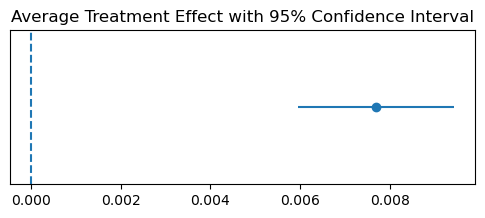

In [16]:
plt.figure(figsize=(6,2))

plt.errorbar(
    x=0.00769,
    y=0,
    xerr=[[0.00769-0.00595],[0.00943-0.00769]],
    fmt='o'
)

plt.axvline(0, linestyle='--')

plt.title("Average Treatment Effect with 95% Confidence Interval")
plt.yticks([])

plt.show()

## Executive Summary

This project evaluated the effectiveness of a digital advertising campaign using A/B testing and causal inference techniques across 588,101 users.

Users were randomly assigned to either an advertisement treatment group or a public service announcement (PSA) control group. Conversion performance was compared to determine whether the advertising intervention produced a measurable improvement in outcomes.

Key findings included:

Advertisement exposure increased conversion rates from 1.79% to 2.55%.
The treatment generated a 42.9% relative improvement in conversions.
A Chi-Square test confirmed that the increase was statistically significant (χ² = 54.01, p < 0.001).
The estimated Average Treatment Effect (ATE) was 0.77 percentage points.
The 95% confidence interval ranged from 0.60 to 0.94 percentage points, providing strong evidence that the treatment effect was positive.

Based on these results, the advertising campaign demonstrated a statistically significant and practically meaningful impact on user conversion behavior and should be considered for broader deployment.